In [88]:
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import math
from pathlib import Path

from xarch_tokenizers.logging.report_utils import load_predictions, load_all_samples, clean_model_name
from xarch_tokenizers.logging.plot_utils import setup_styles, get_new_6_fig, MODEL_TO_COLOR


setup_styles()
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [89]:
METRIC="acc"

## MATH Subset

In [90]:
code_pattern = "*math*"
title_pattern = "MATH - "
base_dir = Path("../results/paper").resolve().absolute()
base_dir.exists()
pred_files = list(
    [p for p in base_dir.rglob(f"samples{code_pattern}.jsonl")]
)
len(pred_files), pred_files[:5]


(88,
 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_cannonical_2025-09-13T10-51-46.408842.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_latex_2025-09-13T10-51-46.408842.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_turkish_2025-09-13T10-51-46.408842.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_decorative_unicode_2025-09-13T10-51-46.408842.jsonl'),
  PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_ma

In [91]:
from xarch_tokenizers.logging.report_utils import load_all_samples

samples = load_all_samples(base_dir, patterns=[code_pattern], flatten_doc=True, match_date=False, simplify_df=True)
samples["model_name"] = samples["model_name"].apply(clean_model_name)
samples["is_canonical"] = samples["variation_id"].apply(lambda x: str(x).split(".")[1]) == "0"
samples.head()
samples["task"].value_counts()

88 [PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_cannonical_2025-09-13T10-51-46.408842.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_latex_2025-09-13T10-51-46.408842.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_turkish_2025-09-13T10-51-46.408842.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_decorative_unicode_2025-09-13T10-51-46.408842.jsonl'), PosixPath('/Users/gsaltintas/code/phd/tokenizers/results/paper/r-three__supertoken_models-llama_facebook-xglm-564M/samples_tokenizer_robustness_completion_math_farsi_20

task
tokenizer_robustness_completion_math_turkish               242
tokenizer_robustness_completion_math_cannonical            231
tokenizer_robustness_completion_math_latex                 231
tokenizer_robustness_completion_math_decorative_unicode    231
tokenizer_robustness_completion_math_farsi                 231
tokenizer_robustness_completion_math_spelled_out           231
tokenizer_robustness_completion_math_chinese               231
tokenizer_robustness_completion_math_italian               231
Name: count, dtype: int64

                     acc
model_name              
Bloom           0.461538
ByT5            0.502959
Comma           0.508876
GPT-2           0.502959
GPT-4o          0.609467
Gemma-2         0.497041
LLaMA           0.556213
MBERT           0.473373
Mistral-Tekken  0.562130
Phi-3           0.573964
XGLM            0.502959


/var/folders/8n/l2sy_xnn4fv5j3b8z0dhfxlh0000gn/T/ipykernel_7031/1415102009.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(accuracies_by_model, x="model_name", y=METRIC, palette="tab10")


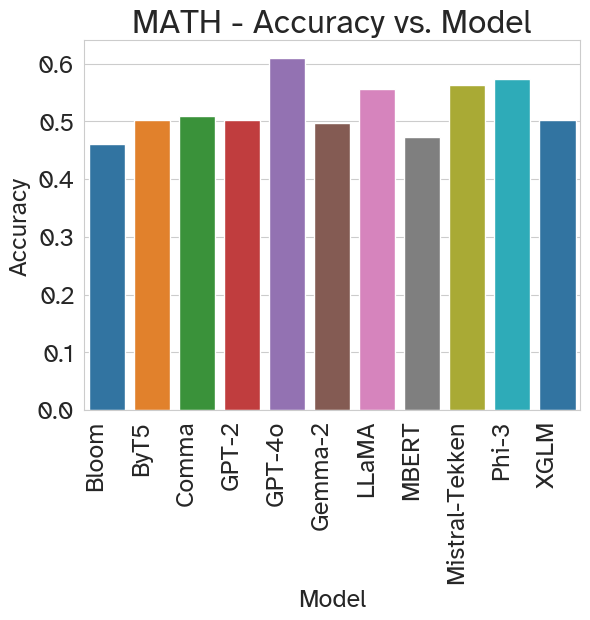

In [92]:
accuracies_by_model = samples.pivot_table(
    index="model_name", values=METRIC, aggfunc="mean"
)
accuracies_by_model
sns.barplot(accuracies_by_model, x="model_name", y=METRIC, palette="tab10")
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title(f"{title_pattern}Accuracy vs. Model")

print(accuracies_by_model)

## Canonical vs. Pertuerbed

                                  acc
model_name     is_canonical          
Bloom          False         0.432432
               True          0.666667
ByT5           False         0.493243
               True          0.571429
Comma          False         0.466216
               True          0.809524
GPT-2          False         0.479730
               True          0.666667
GPT-4o         False         0.574324
               True          0.857143
Gemma-2        False         0.472973
               True          0.666667
LLaMA          False         0.527027
               True          0.761905
MBERT          False         0.472973
               True          0.476190
Mistral-Tekken False         0.533784
               True          0.761905
Phi-3          False         0.554054
               True          0.714286
XGLM           False         0.472973
               True          0.714286


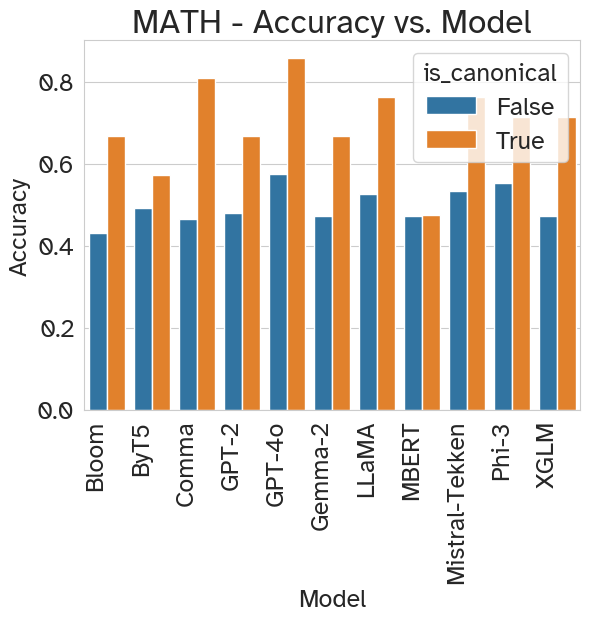

In [93]:
accuracies_by_model = samples.pivot_table(
    index=["model_name", "is_canonical"], values="acc", aggfunc="mean"
)
accuracies_by_model
sns.barplot(accuracies_by_model, x="model_name", y="acc", hue="is_canonical", palette="tab10")
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title(f"{title_pattern}Accuracy vs. Model")

print(accuracies_by_model)

In [94]:
samples["task"].value_counts()

task
tokenizer_robustness_completion_math_turkish               242
tokenizer_robustness_completion_math_cannonical            231
tokenizer_robustness_completion_math_latex                 231
tokenizer_robustness_completion_math_decorative_unicode    231
tokenizer_robustness_completion_math_farsi                 231
tokenizer_robustness_completion_math_spelled_out           231
tokenizer_robustness_completion_math_chinese               231
tokenizer_robustness_completion_math_italian               231
Name: count, dtype: int64

                                            acc
model_name subcategories                       
Bloom      ASCII                       0.666667
           Chinese                     0.523810
           Decorative Unicode          0.333333
           Farsi                       0.380952
           Italian                     0.523810
...                                         ...
XGLM       Italian                     0.523810
           LaTeX                       0.523810
           Spelled out                 0.380952
           Turkish                     0.380952
           Turkish, Numerical formats  0.000000

[99 rows x 1 columns]


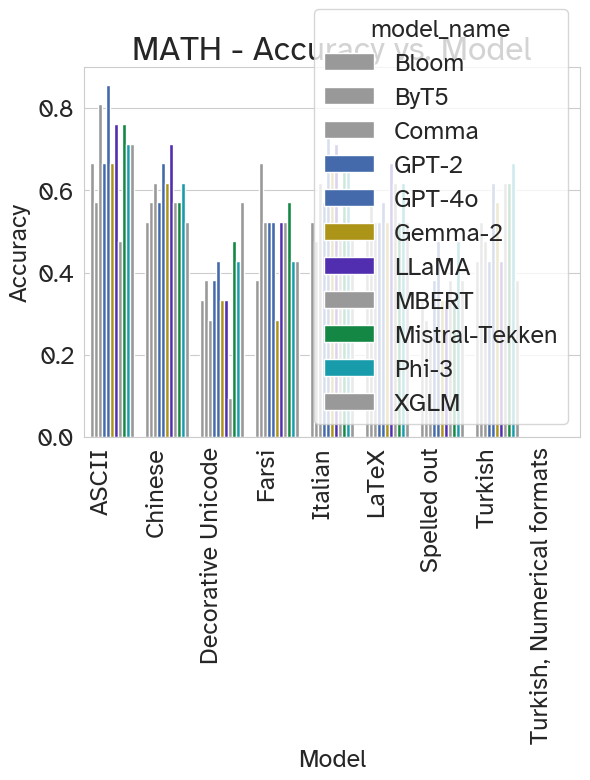

In [97]:
accuracies_by_model = samples.pivot_table(
    index=["model_name", "subcategories"], values="acc", aggfunc="mean"
)
accuracies_by_model
sns.barplot(accuracies_by_model, x="subcategories", y="acc", hue="model_name", palette=MODEL_TO_COLOR)
plt.xticks(rotation=90, ha="right")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title(f"{title_pattern}Accuracy vs. Model")

print(accuracies_by_model)

In [66]:
samples["subcategories"].value_counts()

subcategories
Canonical                                         1012
Code/language/script switching                     847
English keyboard                                   396
Traditional vs Simplified                          363
Word Spacing/Zero-width characters/Extra Space     308
Contractions                                       275
Phonetic spelling                                  253
Homoglyphs                                         253
Romanization                                       242
ASCII                                              231
Italian                                            231
Chinese                                            231
Spelled out                                        231
Decorative Unicode                                 231
Farsi                                              231
LaTeX                                              231
Turkish                                            231
Keyboard proximity errors                          